## PLUTO – Main Simulation

In this notebook, we visualize the progress in our main simulation runs.

### 0. Definitions

#### 0.1. Preamble

In [1]:
%%capture

%config InlineBackend.figure_formats = ['retina']

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import numpy as np
import matplotlib as mpl

import matplotlib.pyplot as plt

import pyPLUTO as pp

import io
import base64

from PIL import Image
from IPython.display import Image as HTML, display
import IPython.display as ipd

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import Normalize, LogNorm
from matplotlib.ticker import ScalarFormatter, MultipleLocator
from matplotlib.patches import Wedge

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["steelblue", "olivedrab", "goldenrod", "firebrick", "rebeccapurple"]) 
plt.rcParams['figure.figsize'] = [8,5]
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True

plt.plot()
plt.close()

#### 0.2. Helpers

In [23]:
def compute_flux_function(D):
    Br = D.Bx1
    theta = D.x2
    r = D.x1
    integrand = Br * (r[:, None]**2) * np.sin(theta)[None, :]
    Psi = np.zeros_like(integrand)
    dtheta = np.diff(theta)
    Psi[:, 1:] = np.cumsum(
        0.5 * (integrand[:, 1:] + integrand[:, :-1]) * dtheta[None, :],
        axis=1
    )
    return Psi



def animate_density(path):
    D_last = pp.Load(nout='last', path=path)
    unique_outs = list(D_last.outlist)

    if 'STAR' in path:
        times = D_last.timelist / 62.8318
    elif 'BH' in path:
        times = D_last.timelist

    R, Theta = np.meshgrid(D_last.x1, D_last.x2, indexing='ij')
    X = R * np.sin(Theta)
    Z = R * np.cos(Theta)
    
    mask = (X >= 0) & (X <= 21) & (Z >= 0) & (Z <= 11)
    
    rho_frames = {}
    for i in unique_outs:
        Di = pp.Load(nout=i, path=path)
        rho_frames[i] = np.where(mask, Di.rho, np.nan)
    
    vmin = np.nanmin([np.nanmin(r) for r in rho_frames.values()])
    vmax = np.nanmax([np.nanmax(r) for r in rho_frames.values()])
    
    if 'STAR' in path:
        outlist = [unique_outs[0]] * 10 + unique_outs + [unique_outs[-1]] * 10
    elif 'BH' in path:
        outlist = [unique_outs[0]] * 20 + unique_outs + [unique_outs[-1]] * 20
    
    frames = []
    for i in outlist:
        fig, ax = plt.subplots(figsize=[6, 8])
        ax.set_facecolor('k')
    
        im = ax.pcolormesh(
            X, Z, rho_frames[i], 
            cmap='magma', 
            norm=LogNorm(vmin=vmin, vmax=vmax), 
            shading='auto'
        )
    
        ax.set_xlabel('R')
        ax.set_ylabel('z')
        ax.set_aspect('equal')
    
        ax.set_xlim(0, 20)
        ax.set_ylim(0, 10)

        if 'STAR' in path:
            ax.add_patch(Wedge((0.0, 0.0), 1.0, 0.0, 90, facecolor='w', edgecolor=None))
            ax.plot([], [], ' ', label=f't = {times[i]:.1f}')
        elif 'BH' in path:
            ax.add_patch(Wedge((0.0, 0.0), 2.1, 0.0, 90, facecolor='k', edgecolor=None))
            ax.plot([], [], ' ', label=f't = {times[i]:.0f}')

        ax.legend(loc='upper right', labelcolor='w')
    
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        fig.colorbar(im, cax=cax, label=r'$\rho$')
    
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=200, bbox_inches='tight')
        plt.close(fig)
        buf.seek(0)
        img = Image.open(buf)
        img.load()
        frames.append(img.convert('RGB'))
    
    gif_path = f'{path}/Storage/density.gif'
    frames[0].save(
        gif_path,
        format='GIF',
        save_all=True,
        append_images=frames[1:],
        duration=150,
        loop=0
    )
    
    ipd.display(ipd.HTML(f'<img src="{gif_path}" width="750">'))



def animate_velocity(path):
    D_last = pp.Load(nout='last', path=path)
    unique_outs = list(D_last.outlist)

    if 'STAR' in path:
        times = D_last.timelist / 62.8318
    elif 'BH' in path:
        times = D_last.timelist
    
    R, Theta = np.meshgrid(D_last.x1, D_last.x2, indexing='ij')
    X = R * np.sin(Theta)
    Z = R * np.cos(Theta)
    
    mask = (X >= 0) & (X <= 21) & (Z >= 0) & (Z <= 11)
    
    rho_frames = {}
    vx_frames = {}
    vz_frames = {}
    vr_frames = {}
    for i in unique_outs:
        Di = pp.Load(nout=i, path=path)
        rho_frames[i] = np.where(mask, Di.rho, np.nan)
    
        vr = Di.vx1
        vth = Di.vx2
        vx = vr * np.sin(Theta) + vth * np.cos(Theta)
        vz = vr * np.cos(Theta) - vth * np.sin(Theta)
    
        vx_frames[i] = np.where(mask, vx, np.nan)
        vz_frames[i] = np.where(mask, vz, np.nan)
        vr_frames[i] = np.where(mask, vr, np.nan)
    
    vmin = np.nanmin([np.nanmin(r) for r in rho_frames.values()])
    vmax = np.nanmax([np.nanmax(r) for r in rho_frames.values()])
    
    stride1, stride2 = 1, 1
    
    if 'STAR' in path:
        outlist = [unique_outs[0]] * 10 + unique_outs + [unique_outs[-1]] * 10
    elif 'BH' in path:
        outlist = [unique_outs[0]] * 20 + unique_outs + [unique_outs[-1]] * 20

    frames = []
    for i in outlist:
        fig, ax = plt.subplots(figsize=[6, 8])
        ax.set_facecolor('k')
        im = ax.pcolormesh(
            X, Z, rho_frames[i],
            cmap='gray',
            norm=LogNorm(vmin=vmin, vmax=vmax),
            shading='auto'
        )
        Xq = X[::stride1, ::stride2]
        Zq = Z[::stride1, ::stride2]
        Uq = vx_frames[i][::stride1, ::stride2]
        Wq = vz_frames[i][::stride1, ::stride2]
        Vrq = vr_frames[i][::stride1, ::stride2]
    
        colors = np.where(Vrq >= 0, 'r', 'b').ravel()
    
        ax.quiver(
            Xq, Zq, Uq, Wq,
            color=colors,
            scale_units='xy',
            angles='xy',
        )
        ax.set_xlabel('R')
        ax.set_ylabel('z')
        ax.set_aspect('equal')
        ax.set_xlim(0, 20)
        ax.set_ylim(0, 10)

        if 'STAR' in path:
            ax.add_patch(Wedge((0.0, 0.0), 1.0, 0.0, 90, facecolor='w', edgecolor=None))
            ax.plot([], [], ' ', label=f't = {times[i]:.1f}')
        elif 'BH' in path:
            ax.add_patch(Wedge((0.0, 0.0), 2.1, 0.0, 90, facecolor='k', edgecolor=None))
            ax.plot([], [], ' ', label=f't = {times[i]:.0f}')

        ax.legend(loc='upper right', labelcolor='w')
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        fig.colorbar(im, cax=cax, label=r'$\rho$')
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=200, bbox_inches='tight')
        plt.close(fig)
        buf.seek(0)
        img = Image.open(buf)
        img.load()
        frames.append(img.convert('RGB'))
    
    gif_path = f'{path}/Storage/velocity.gif'
    frames[0].save(
        gif_path,
        format='GIF',
        save_all=True,
        append_images=frames[1:],
        duration=150,
        loop=0
    )
    
    ipd.display(ipd.HTML(f'<img src="{gif_path}" width="750">'))



def animate_field(path):
    D_last = pp.Load(nout='last', path=path)
    unique_outs = list(D_last.outlist)

    if 'STAR' in path:
        times = D_last.timelist / 62.8318
    elif 'BH' in path:
        times = D_last.timelist

    R, Theta = np.meshgrid(D_last.x1, D_last.x2, indexing='ij')
    X = R * np.sin(Theta)
    Z = R * np.cos(Theta)

    mask = (X >= 0) & (X <= 21) & (Z >= 0) & (Z <= 11)

    rho_frames = {}
    Psi_frames = {}
    for i in unique_outs:
        Di = pp.Load(nout=i, path=path)
        rho_frames[i] = np.where(mask, Di.rho, np.nan)
        Psi_frames[i] = compute_flux_function(Di)

    vmin = np.nanmin([np.nanmin(r) for r in rho_frames.values()])
    vmax = np.nanmax([np.nanmax(r) for r in rho_frames.values()])

    global_absmax = max(np.nanmax(np.abs(p)) for p in Psi_frames.values())
    levels_pos = np.linspace(0, global_absmax, 100)
    levels_neg = -levels_pos[::-1]

    if 'STAR' in path:
        outlist = [unique_outs[0]] * 10 + unique_outs + [unique_outs[-1]] * 10
    elif 'BH' in path:
        outlist = [unique_outs[0]] * 20 + unique_outs + [unique_outs[-1]] * 20

    frames = []
    for i in outlist:
        fig, ax = plt.subplots(figsize=[6, 8])
        ax.set_facecolor('k')

        im = ax.pcolormesh(
            X, Z, rho_frames[i],
            cmap='gray',
            norm=LogNorm(vmin=vmin, vmax=vmax),
            shading='auto'
        )

        ax.contour(X, Z, Psi_frames[i], levels=levels_pos, colors='m', linestyle='-', linewidths=0.4)
        ax.contour(X, Z, Psi_frames[i], levels=levels_neg, colors='m', linestyle='-', linewidths=0.4)

        ax.set_xlabel('R')
        ax.set_ylabel('z')
        ax.set_aspect('equal')
        ax.set_xlim(0, 20)
        ax.set_ylim(0, 10)

        if 'STAR' in path:
            ax.add_patch(Wedge((0.0, 0.0), 1.0, 0.0, 90, facecolor='w', edgecolor=None))
            ax.plot([], [], ' ', label=f't = {times[i]:.1f}')
        elif 'BH' in path:
            ax.add_patch(Wedge((0.0, 0.0), 2.1, 0.0, 90, facecolor='k', edgecolor=None))
            ax.plot([], [], ' ', label=f't = {times[i]:.0f}')

        ax.legend(loc='upper right', labelcolor='w')

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        fig.colorbar(im, cax=cax, label=r'$\rho$')

        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=200, bbox_inches='tight')
        plt.close(fig)
        buf.seek(0)
        img = Image.open(buf)
        img.load()
        frames.append(img.convert('RGB'))

    gif_path = f'{path}/Storage/field.gif'
    frames[0].save(
        gif_path,
        format='GIF',
        save_all=True,
        append_images=frames[1:],
        duration=150,
        loop=0
    )

    ipd.display(ipd.HTML(f'<img src="{gif_path}" width="750">'))



def animate_tracer(path):
    D_last = pp.Load(nout='last', path=path)
    unique_outs = list(D_last.outlist)
    if 'STAR' in path:
        times = D_last.timelist / 62.8318
    elif 'BH' in path:
        times = D_last.timelist
    R, Theta = np.meshgrid(D_last.x1, D_last.x2, indexing='ij')
    X = R * np.sin(Theta)
    Z = R * np.cos(Theta)

    mask = (X >= 0) & (X <= 21) & (Z >= 0) & (Z <= 11)

    trc_frames = {}
    for i in unique_outs:
        Di = pp.Load(nout=i, path=path)
        trc_frames[i] = np.where(mask, Di.tr1, np.nan)

    if 'STAR' in path:
        outlist = [unique_outs[0]] * 10 + unique_outs + [unique_outs[-1]] * 10
    elif 'BH' in path:
        outlist = [unique_outs[0]] * 20 + unique_outs + [unique_outs[-1]] * 20

    frames = []
    for i in outlist:
        fig, ax = plt.subplots(figsize=[6, 8])
        ax.set_facecolor('k')

        im = ax.pcolormesh(
            X, Z, trc_frames[i],
            cmap='bwr',
            vmin=0, vmax=1,
            shading='auto'
        )

        ax.set_xlabel('R')
        ax.set_ylabel('z')
        ax.set_aspect('equal')

        ax.set_xlim(0, 20)
        ax.set_ylim(0, 10)
        if 'STAR' in path:
            ax.add_patch(Wedge((0.0, 0.0), 1.0, 0.0, 90, facecolor='w', edgecolor=None))
            ax.plot([], [], ' ', label=f't = {times[i]:.1f}')
        elif 'BH' in path:
            ax.add_patch(Wedge((0.0, 0.0), 2.1, 0.0, 90, facecolor='k', edgecolor=None))
            ax.plot([], [], ' ', label=f't = {times[i]:.0f}')
        ax.legend(loc='upper right', labelcolor='w')

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.4)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_ticks([])

        cax.text(0.5, 1.02, 'disk', transform=cax.transAxes,
                  ha='center', va='bottom', color='k', fontsize=10)
        cax.text(0.5, -0.02, 'corona', transform=cax.transAxes,
                  ha='center', va='top', color='k', fontsize=10)

        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=200, bbox_inches='tight')
        plt.close(fig)
        buf.seek(0)
        img = Image.open(buf)
        img.load()
        frames.append(img.convert('RGB'))

    gif_path = f'{path}/Storage/tracer.gif'
    frames[0].save(
        gif_path,
        format='GIF',
        save_all=True,
        append_images=frames[1:],
        duration=150,
        loop=0
    )

    ipd.display(ipd.HTML(f'<img src="{gif_path}" width="750">'))



def animate_panel(path):
    D_last = pp.Load(nout='last', path=path)
    unique_outs = list(D_last.outlist)
    if 'STAR' in path:
        times = D_last.timelist / 62.8318
    elif 'BH' in path:
        times = D_last.timelist

    def profiles(D):
        rho = D.rho
        prs = D.prs
        vr = D.vx1
        vphi = D.vx3
        tr = D.tr1
        theta = D.x2
        r = D.x1

        sin_th = np.sin(theta)[None, :]
        l_specific = r[:, None] * np.sin(theta)[None, :] * vphi

        def weighted_avg(field, weight):
            num = np.trapezoid(field * weight * sin_th, theta, axis=1)
            den = np.trapezoid(weight * sin_th, theta, axis=1)
            return num / np.where(den == 0, np.nan, den)

        rho_disk = weighted_avg(rho, tr)
        rho_corona = weighted_avg(rho, 1 - tr)
        prs_disk = weighted_avg(prs, tr)
        prs_corona = weighted_avg(prs, 1 - tr)

        base = rho * vr * sin_th
        base_l = rho * vr * l_specific * sin_th
        Mdot_disk = 2 * np.pi * r**2 * np.trapezoid(base * tr, theta, axis=1)
        Mdot_corona = 2 * np.pi * r**2 * np.trapezoid(base * (1 - tr), theta, axis=1)
        Ldot_disk = 2 * np.pi * r**2 * np.trapezoid(base_l * tr, theta, axis=1)
        Ldot_corona = 2 * np.pi * r**2 * np.trapezoid(base_l * (1 - tr), theta, axis=1)

        return (r, rho_disk, rho_corona, prs_disk, prs_corona,
                Mdot_disk, Mdot_corona, Ldot_disk, Ldot_corona)

    r_ref = None
    rho_disk_frames, rho_corona_frames = {}, {}
    prs_disk_frames, prs_corona_frames = {}, {}
    Mdot_disk_frames, Mdot_corona_frames = {}, {}
    Ldot_disk_frames, Ldot_corona_frames = {}, {}

    for i in unique_outs:
        Di = pp.Load(nout=i, path=path)
        r, rd, rc, pd, pc, md, mc, ld, lc = profiles(Di)
        r_ref = r
        rho_disk_frames[i] = rd
        rho_corona_frames[i] = rc
        prs_disk_frames[i] = pd
        prs_corona_frames[i] = pc
        Mdot_disk_frames[i] = md
        Mdot_corona_frames[i] = mc
        Ldot_disk_frames[i] = ld
        Ldot_corona_frames[i] = lc

    def shared_ylim(*frame_dicts, log=False):
        all_vals = np.concatenate([v[~np.isnan(v)] for d in frame_dicts for v in d.values()])
        if log:
            all_vals = all_vals[all_vals > 0]
            ymin, ymax = all_vals.min(), all_vals.max()
            pad = (ymax / ymin) ** 0.05
            return ymin / pad, ymax * pad
        ymin, ymax = all_vals.min(), all_vals.max()
        pad = 0.05 * (ymax - ymin)
        return ymin - pad, ymax + pad

    rho_ymin, rho_ymax = shared_ylim(rho_disk_frames, rho_corona_frames, log=True)
    prs_ymin, prs_ymax = shared_ylim(prs_disk_frames, prs_corona_frames, log=True)
    mdot_ymin, mdot_ymax = shared_ylim(Mdot_disk_frames, Mdot_corona_frames)
    ldot_ymin, ldot_ymax = shared_ylim(Ldot_disk_frames, Ldot_corona_frames)

    outlist = [unique_outs[0]] * 10 + unique_outs + [unique_outs[-1]] * 10

    frames = []
    for i in outlist:
        fig, axs = plt.subplots(4, 2, figsize=[7.5, 10], sharex=True)

        for col, frame_dict in [(0, rho_disk_frames), (1, rho_corona_frames)]:
            ax = axs[0, col]
            y = frame_dict[i]
            ax.fill_between(r_ref, y, rho_ymin, color='m', alpha=1/4, linewidth=0)
            ax.set_yscale('log')
            ax.set_ylim(rho_ymin, rho_ymax)
            if col == 0:
                ax.set_ylabel(r'$\langle\rho\rangle$')

        for col, frame_dict in [(0, prs_disk_frames), (1, prs_corona_frames)]:
            ax = axs[1, col]
            y = frame_dict[i]
            ax.fill_between(r_ref, y, prs_ymin, color='m', alpha=1/4, linewidth=0)
            ax.set_yscale('log')
            ax.set_ylim(prs_ymin, prs_ymax)
            if col == 0:
                ax.set_ylabel(r'$\langle P\rangle$')

        panel_spec = [
            (2, 0, Mdot_disk_frames,   r'$\dot{M}$',    mdot_ymin, mdot_ymax),
            (2, 1, Mdot_corona_frames, None,            mdot_ymin, mdot_ymax),
            (3, 0, Ldot_disk_frames,   r'$\dot{L}$',    ldot_ymin, ldot_ymax),
            (3, 1, Ldot_corona_frames, None,            ldot_ymin, ldot_ymax),
        ]
        for row, col, frame_dict, ylabel, ymin, ymax in panel_spec:
            ax = axs[row, col]
            y = frame_dict[i]
            ax.axhline(0, color='k', lw=0.8, ls='-')
            ax.fill_between(r_ref, y, 0, where=(y < 0), color='b', alpha=1/3, linewidth=0)
            ax.fill_between(r_ref, y, 0, where=(y >= 0), color='r', alpha=1/3, linewidth=0)
            ax.set_ylabel(ylabel)
            ax.set_ylim(ymin, ymax)

        for row in range(4):
            for col in range(2):
                ax = axs[row, col]
                ax.set_xscale('log')
                ax.set_xticks([2, 4, 6, 8, 10, 20, 30])
                ax.xaxis.set_major_formatter(ScalarFormatter())
                ax.minorticks_off()
                ax.xaxis.set_minor_formatter(plt.NullFormatter())
                if row == 3:
                    ax.set_xlabel(r'$r$')

        axs[0, 0].set_title('Disk')
        axs[0, 1].set_title('Corona')
        for row in range(4):
            axs[row, 1].tick_params(labelleft=False)

        if 'STAR' in path:
            axs[0, 1].plot([], [], ' ', label=f't = {times[i]:.1f}')
        elif 'BH' in path:
            axs[0, 1].plot([], [], ' ', label=f't = {times[i]:.0f}')
        axs[0, 1].legend(loc='upper right')

        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=200, bbox_inches='tight')
        plt.close(fig)
        buf.seek(0)
        img = Image.open(buf)
        img.load()
        frames.append(img.convert('RGB'))

    gif_path = f'{path}/Storage/panel.gif'
    frames[0].save(
        gif_path,
        format='GIF',
        save_all=True,
        append_images=frames[1:],
        duration=150,
        loop=0
    )
    ipd.display(ipd.HTML(f'<img src="{gif_path}" width="750">'))

### 1. Plots

In [3]:
path = 'BH_VISC_HD/'
animate_density(path)
animate_velocity(path)
animate_panel(path)

In [5]:
path = 'BH_VISC_MHD/'
animate_density(path)
animate_velocity(path)
animate_field(path)
animate_panel(path)

In [6]:
path = 'BH_VISC_RES_MHD/'
animate_density(path)
animate_velocity(path)
animate_field(path)
animate_panel(path)

In [24]:
path = 'BH_VISC_HD/'
animate_tracer(path)

In [25]:
def animate_disk_otsu(path, mode='binary', sharpness=6.0, compare_to_tracer=False):
    """
    Reproduces animate_tracer, but computes disk/corona membership via a
    per-radius Otsu threshold on log(rho) instead of reading the PLUTO tracer.

    mode: 'binary' -> hard 0/1 Otsu split
          'sigmoid' -> smooth field around the Otsu threshold
    compare_to_tracer: if True, also loads tr1 and prints per-frame agreement
                        fraction (for validating against known-tracer runs)
    """
    from skimage.filters import threshold_otsu

    D_last = pp.Load(nout='last', path=path)
    unique_outs = list(D_last.outlist)
    if 'STAR' in path:
        times = D_last.timelist / 62.8318
    elif 'BH' in path:
        times = D_last.timelist
    R, Theta = np.meshgrid(D_last.x1, D_last.x2, indexing='ij')
    X = R * np.sin(Theta)
    Z = R * np.cos(Theta)

    mask = (X >= 0) & (X <= 21) & (Z >= 0) & (Z <= 11)

    def otsu_field(rho):
        field = np.zeros_like(rho)
        for i in range(rho.shape[0]):
            logrho = np.log10(np.clip(rho[i, :], 1e-30, None))
            if logrho.max() - logrho.min() < 1e-6:
                continue  # no contrast at this radius -> leave as corona (0)
            t = threshold_otsu(logrho)
            if mode == 'binary':
                field[i, :] = (logrho > t).astype(float)
            else:
                field[i, :] = 1. / (1. + np.exp(-sharpness * (logrho - t)))
        return field

    disk_frames = {}
    for i in unique_outs:
        Di = pp.Load(nout=i, path=path)
        field = otsu_field(Di.rho)
        disk_frames[i] = np.where(mask, field, np.nan)

        if compare_to_tracer:
            agree = np.nanmean(
                (field > 0.5).astype(float) == (Di.tr1 > 0.5).astype(float)
            )
            print(f"nout {i}: Otsu/tracer agreement = {agree:.3f}")

    if 'STAR' in path:
        outlist = [unique_outs[0]] * 10 + unique_outs + [unique_outs[-1]] * 10
    elif 'BH' in path:
        outlist = [unique_outs[0]] * 20 + unique_outs + [unique_outs[-1]] * 20

    frames = []
    for i in outlist:
        fig, ax = plt.subplots(figsize=[6, 8])
        ax.set_facecolor('k')

        im = ax.pcolormesh(
            X, Z, disk_frames[i],
            cmap='bwr',
            vmin=0, vmax=1,
            shading='auto'
        )

        ax.set_xlabel('R')
        ax.set_ylabel('z')
        ax.set_aspect('equal')

        ax.set_xlim(0, 20)
        ax.set_ylim(0, 10)
        if 'STAR' in path:
            ax.add_patch(Wedge((0.0, 0.0), 1.0, 0.0, 90, facecolor='w', edgecolor=None))
            ax.plot([], [], ' ', label=f't = {times[i]:.1f}')
        elif 'BH' in path:
            ax.add_patch(Wedge((0.0, 0.0), 2.1, 0.0, 90, facecolor='k', edgecolor=None))
            ax.plot([], [], ' ', label=f't = {times[i]:.0f}')
        ax.legend(loc='upper right', labelcolor='w')

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.4)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_ticks([])

        cax.text(0.5, 1.02, 'disk', transform=cax.transAxes,
                  ha='center', va='bottom', color='k', fontsize=10)
        cax.text(0.5, -0.02, 'corona', transform=cax.transAxes,
                  ha='center', va='top', color='k', fontsize=10)

        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=200, bbox_inches='tight')
        plt.close(fig)
        buf.seek(0)
        img = Image.open(buf)
        img.load()
        frames.append(img.convert('RGB'))

    gif_path = f'{path}/Storage/disk_otsu.gif'
    frames[0].save(
        gif_path,
        format='GIF',
        save_all=True,
        append_images=frames[1:],
        duration=150,
        loop=0
    )

    ipd.display(ipd.HTML(f'<img src="{gif_path}" width="750">'))

In [29]:
path = 'BH_VISC_HD/'
animate_disk_otsu(path, mode='binary')

In [28]:
path = 'BH_VISC_HD/'
animate_disk_otsu(path, mode='sigmoid')

In [30]:
path = 'BH_VISC_HD/'
animate_disk_otsu(path, mode='binary', compare_to_tracer=True)

nout 0: Otsu/tracer agreement = 1.000
nout 1: Otsu/tracer agreement = 0.891
nout 2: Otsu/tracer agreement = 0.883
nout 3: Otsu/tracer agreement = 0.988
nout 4: Otsu/tracer agreement = 0.989
nout 5: Otsu/tracer agreement = 0.987
nout 6: Otsu/tracer agreement = 0.986
nout 7: Otsu/tracer agreement = 0.989
nout 8: Otsu/tracer agreement = 0.981
nout 9: Otsu/tracer agreement = 0.986
nout 10: Otsu/tracer agreement = 0.988
nout 11: Otsu/tracer agreement = 0.985
nout 12: Otsu/tracer agreement = 0.989
nout 13: Otsu/tracer agreement = 0.988
nout 14: Otsu/tracer agreement = 0.987
nout 15: Otsu/tracer agreement = 0.986
nout 16: Otsu/tracer agreement = 0.988
nout 17: Otsu/tracer agreement = 0.988
nout 18: Otsu/tracer agreement = 0.990
nout 19: Otsu/tracer agreement = 0.987
nout 20: Otsu/tracer agreement = 0.988
nout 21: Otsu/tracer agreement = 0.986
nout 22: Otsu/tracer agreement = 0.985
nout 23: Otsu/tracer agreement = 0.984
nout 24: Otsu/tracer agreement = 0.987
nout 25: Otsu/tracer agreement = 0.

In [31]:
path = 'BH_VISC_HD/'
animate_disk_otsu(path, mode='sigmoid', compare_to_tracer=True)

nout 0: Otsu/tracer agreement = 1.000
nout 1: Otsu/tracer agreement = 0.891
nout 2: Otsu/tracer agreement = 0.883
nout 3: Otsu/tracer agreement = 0.988
nout 4: Otsu/tracer agreement = 0.989
nout 5: Otsu/tracer agreement = 0.987
nout 6: Otsu/tracer agreement = 0.986
nout 7: Otsu/tracer agreement = 0.989
nout 8: Otsu/tracer agreement = 0.981
nout 9: Otsu/tracer agreement = 0.986
nout 10: Otsu/tracer agreement = 0.988
nout 11: Otsu/tracer agreement = 0.985
nout 12: Otsu/tracer agreement = 0.989
nout 13: Otsu/tracer agreement = 0.988
nout 14: Otsu/tracer agreement = 0.987
nout 15: Otsu/tracer agreement = 0.986
nout 16: Otsu/tracer agreement = 0.988
nout 17: Otsu/tracer agreement = 0.988
nout 18: Otsu/tracer agreement = 0.990
nout 19: Otsu/tracer agreement = 0.987
nout 20: Otsu/tracer agreement = 0.988
nout 21: Otsu/tracer agreement = 0.986
nout 22: Otsu/tracer agreement = 0.985
nout 23: Otsu/tracer agreement = 0.984
nout 24: Otsu/tracer agreement = 0.987
nout 25: Otsu/tracer agreement = 0.

In [32]:
def animate_disk_otsu(path, mode='binary', sharpness=6.0, compare_to_tracer=False,
                       connected_component=False, min_component_frac=0.0):
    """
    Reproduces animate_tracer, but computes disk/corona membership via a
    per-radius Otsu threshold on log(rho) instead of reading the PLUTO tracer.

    mode: 'binary' -> hard 0/1 Otsu split
          'sigmoid' -> smooth field around the Otsu threshold
    compare_to_tracer: if True, also loads tr1 and prints per-frame agreement
                        fraction (for validating against known-tracer runs)
    connected_component: if True, keep only the largest connected component
                          of the binary Otsu field (filters out disconnected
                          outflow blobs). Applied to the binary version even
                          when mode='sigmoid' (see note below).
    min_component_frac: if >0, also keep components with size >=
                         min_component_frac * largest_component_size,
                         instead of only the single largest one
    """
    from skimage.filters import threshold_otsu
    from scipy.ndimage import label

    D_last = pp.Load(nout='last', path=path)
    unique_outs = list(D_last.outlist)
    if 'STAR' in path:
        times = D_last.timelist / 62.8318
    elif 'BH' in path:
        times = D_last.timelist
    R, Theta = np.meshgrid(D_last.x1, D_last.x2, indexing='ij')
    X = R * np.sin(Theta)
    Z = R * np.cos(Theta)
    mask = (X >= 0) & (X <= 21) & (Z >= 0) & (Z <= 11)

    def otsu_field(rho):
        field = np.zeros_like(rho)
        for i in range(rho.shape[0]):
            logrho = np.log10(np.clip(rho[i, :], 1e-30, None))
            if logrho.max() - logrho.min() < 1e-6:
                continue  # no contrast at this radius -> leave as corona (0)
            t = threshold_otsu(logrho)
            if mode == 'binary':
                field[i, :] = (logrho > t).astype(float)
            else:
                field[i, :] = 1. / (1. + np.exp(-sharpness * (logrho - t)))
        return field

    def apply_connected_component(field):
        # operate on the binary version regardless of mode, since connectivity
        # is a topological notion; for sigmoid we then re-mask the continuous
        # field so cells outside the kept component(s) are forced to 0
        binary = field > 0.5
        labeled, n = label(binary)
        if n == 0:
            return field
        sizes = np.array([(labeled == k).sum() for k in range(1, n + 1)])
        largest = sizes.max()
        keep_labels = np.where(sizes >= min_component_frac * largest)[0] + 1
        keep_mask = np.isin(labeled, keep_labels)
        out = field.copy()
        out[~keep_mask] = 0.0
        return out

    disk_frames = {}
    for i in unique_outs:
        Di = pp.Load(nout=i, path=path)
        field = otsu_field(Di.rho)
        if connected_component:
            field = apply_connected_component(field)
        disk_frames[i] = np.where(mask, field, np.nan)
        if compare_to_tracer:
            agree = np.nanmean(
                (field > 0.5).astype(float) == (Di.tr1 > 0.5).astype(float)
            )
            print(f"nout {i}: Otsu/tracer agreement = {agree:.3f}")

    if 'STAR' in path:
        outlist = [unique_outs[0]] * 10 + unique_outs + [unique_outs[-1]] * 10
    elif 'BH' in path:
        outlist = [unique_outs[0]] * 20 + unique_outs + [unique_outs[-1]] * 20

    frames = []
    for i in outlist:
        fig, ax = plt.subplots(figsize=[6, 8])
        ax.set_facecolor('k')
        im = ax.pcolormesh(
            X, Z, disk_frames[i],
            cmap='bwr',
            vmin=0, vmax=1,
            shading='auto'
        )
        ax.set_xlabel('R')
        ax.set_ylabel('z')
        ax.set_aspect('equal')
        ax.set_xlim(0, 20)
        ax.set_ylim(0, 10)
        if 'STAR' in path:
            ax.add_patch(Wedge((0.0, 0.0), 1.0, 0.0, 90, facecolor='w', edgecolor=None))
            ax.plot([], [], ' ', label=f't = {times[i]:.1f}')
        elif 'BH' in path:
            ax.add_patch(Wedge((0.0, 0.0), 2.1, 0.0, 90, facecolor='k', edgecolor=None))
            ax.plot([], [], ' ', label=f't = {times[i]:.0f}')
        ax.legend(loc='upper right', labelcolor='w')
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.4)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_ticks([])
        cax.text(0.5, 1.02, 'disk', transform=cax.transAxes,
                  ha='center', va='bottom', color='k', fontsize=10)
        cax.text(0.5, -0.02, 'corona', transform=cax.transAxes,
                  ha='center', va='top', color='k', fontsize=10)
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=200, bbox_inches='tight')
        plt.close(fig)
        buf.seek(0)
        img = Image.open(buf)
        img.load()
        frames.append(img.convert('RGB'))
    gif_path = f'{path}/Storage/disk_otsu.gif'
    frames[0].save(
        gif_path,
        format='GIF',
        save_all=True,
        append_images=frames[1:],
        duration=150,
        loop=0
    )
    ipd.display(ipd.HTML(f'<img src="{gif_path}" width="750">'))

In [35]:
path = 'BH_VISC_HD/'
animate_disk_otsu(path, mode='binary', connected_component=True, min_component_frac=0.9)

In [36]:
def animate_disk_otsu(path, mode='binary', sharpness=6.0, compare_to_tracer=False,
                       connected_component=False, min_component_frac=0.0):
    """
    Reproduces animate_tracer, but computes disk/corona membership via a
    per-radius Otsu threshold on log(rho) instead of reading the PLUTO tracer.

    mode: 'binary' -> hard 0/1 Otsu split
          'sigmoid' -> smooth field around the Otsu threshold
    compare_to_tracer: if True, also loads tr1 and prints per-frame agreement
                        fraction (for validating against known-tracer runs)
    connected_component: if True, keep only connected components whose
                          physical (r*dr*dtheta) area is at least
                          min_component_frac * area_of_largest_component
    min_component_frac: fraction (0-1) of the largest component's area a
                         component must have to survive filtering; 0.0 keeps
                         everything, 1.0 keeps only the single largest
    """
    from skimage.filters import threshold_otsu
    from scipy.ndimage import label

    D_last = pp.Load(nout='last', path=path)
    unique_outs = list(D_last.outlist)
    if 'STAR' in path:
        times = D_last.timelist / 62.8318
    elif 'BH' in path:
        times = D_last.timelist
    R, Theta = np.meshgrid(D_last.x1, D_last.x2, indexing='ij')
    X = R * np.sin(Theta)
    Z = R * np.cos(Theta)
    mask = (X >= 0) & (X <= 21) & (Z >= 0) & (Z <= 11)

    # precompute area-weighting grid once (shared across all frames)
    dr = np.gradient(R[:, 0])
    dtheta = np.gradient(Theta[0, :])
    cell_area = R * dr[:, None] * dtheta[None, :]

    def otsu_field(rho):
        field = np.zeros_like(rho)
        for i in range(rho.shape[0]):
            logrho = np.log10(np.clip(rho[i, :], 1e-30, None))
            if logrho.max() - logrho.min() < 1e-6:
                continue  # no contrast at this radius -> leave as corona (0)
            t = threshold_otsu(logrho)
            if mode == 'binary':
                field[i, :] = (logrho > t).astype(float)
            else:
                field[i, :] = 1. / (1. + np.exp(-sharpness * (logrho - t)))
        return field

    def apply_connected_component(field):
        binary = field > 0.5
        labeled, n = label(binary)
        if n == 0:
            return field
        areas = np.array([cell_area[labeled == k].sum() for k in range(1, n + 1)])
        largest = areas.max()
        keep_labels = np.where(areas >= min_component_frac * largest)[0] + 1
        keep_mask = np.isin(labeled, keep_labels)
        out = field.copy()
        out[~keep_mask] = 0.0
        return out

    disk_frames = {}
    for i in unique_outs:
        Di = pp.Load(nout=i, path=path)
        field = otsu_field(Di.rho)
        if connected_component:
            field = apply_connected_component(field)
        disk_frames[i] = np.where(mask, field, np.nan)
        if compare_to_tracer:
            agree = np.nanmean(
                (field > 0.5).astype(float) == (Di.tr1 > 0.5).astype(float)
            )
            print(f"nout {i}: Otsu/tracer agreement = {agree:.3f}")

    if 'STAR' in path:
        outlist = [unique_outs[0]] * 10 + unique_outs + [unique_outs[-1]] * 10
    elif 'BH' in path:
        outlist = [unique_outs[0]] * 20 + unique_outs + [unique_outs[-1]] * 20

    frames = []
    for i in outlist:
        fig, ax = plt.subplots(figsize=[6, 8])
        ax.set_facecolor('k')
        im = ax.pcolormesh(
            X, Z, disk_frames[i],
            cmap='bwr',
            vmin=0, vmax=1,
            shading='auto'
        )
        ax.set_xlabel('R')
        ax.set_ylabel('z')
        ax.set_aspect('equal')
        ax.set_xlim(0, 20)
        ax.set_ylim(0, 10)
        if 'STAR' in path:
            ax.add_patch(Wedge((0.0, 0.0), 1.0, 0.0, 90, facecolor='w', edgecolor=None))
            ax.plot([], [], ' ', label=f't = {times[i]:.1f}')
        elif 'BH' in path:
            ax.add_patch(Wedge((0.0, 0.0), 2.1, 0.0, 90, facecolor='k', edgecolor=None))
            ax.plot([], [], ' ', label=f't = {times[i]:.0f}')
        ax.legend(loc='upper right', labelcolor='w')
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.4)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_ticks([])
        cax.text(0.5, 1.02, 'disk', transform=cax.transAxes,
                  ha='center', va='bottom', color='k', fontsize=10)
        cax.text(0.5, -0.02, 'corona', transform=cax.transAxes,
                  ha='center', va='top', color='k', fontsize=10)
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=200, bbox_inches='tight')
        plt.close(fig)
        buf.seek(0)
        img = Image.open(buf)
        img.load()
        frames.append(img.convert('RGB'))
    gif_path = f'{path}/Storage/disk_otsu.gif'
    frames[0].save(
        gif_path,
        format='GIF',
        save_all=True,
        append_images=frames[1:],
        duration=150,
        loop=0
    )
    ipd.display(ipd.HTML(f'<img src="{gif_path}" width="750">'))

In [38]:
path = 'BH_VISC_HD/'
animate_disk_otsu(path, mode='binary', compare_to_tracer=True, connected_component=True, min_component_frac=0.9)

nout 0: Otsu/tracer agreement = 1.000
nout 1: Otsu/tracer agreement = 0.898
nout 2: Otsu/tracer agreement = 0.886
nout 3: Otsu/tracer agreement = 0.990
nout 4: Otsu/tracer agreement = 0.990
nout 5: Otsu/tracer agreement = 0.989
nout 6: Otsu/tracer agreement = 0.989
nout 7: Otsu/tracer agreement = 0.990
nout 8: Otsu/tracer agreement = 0.988
nout 9: Otsu/tracer agreement = 0.989
nout 10: Otsu/tracer agreement = 0.989
nout 11: Otsu/tracer agreement = 0.988
nout 12: Otsu/tracer agreement = 0.990
nout 13: Otsu/tracer agreement = 0.989
nout 14: Otsu/tracer agreement = 0.989
nout 15: Otsu/tracer agreement = 0.988
nout 16: Otsu/tracer agreement = 0.990
nout 17: Otsu/tracer agreement = 0.989
nout 18: Otsu/tracer agreement = 0.990
nout 19: Otsu/tracer agreement = 0.990
nout 20: Otsu/tracer agreement = 0.990
nout 21: Otsu/tracer agreement = 0.989
nout 22: Otsu/tracer agreement = 0.990
nout 23: Otsu/tracer agreement = 0.990
nout 24: Otsu/tracer agreement = 0.993
nout 25: Otsu/tracer agreement = 0.

In [39]:
def compare_otsu_median(path, factors=(3, 5, 10, 20), nouts=None):
    """
    Validates a per-radius median-ratio classifier against the Otsu classifier
    (and, where available, tracer truth) on relaxed output.

    factors: candidate multipliers for `rho > factor * median(rho at this r)`
    nouts: list of output indices to check; defaults to a few late (relaxed)
           outputs plus the last one
    """
    from skimage.filters import threshold_otsu

    D_last = pp.Load(nout='last', path=path)
    unique_outs = list(D_last.outlist)

    if nouts is None:
        # default to late/relaxed outputs: last one plus a few before it
        nouts = unique_outs[-5:] if len(unique_outs) >= 5 else unique_outs

    def otsu_field(rho):
        field = np.zeros_like(rho)
        thresholds = np.full(rho.shape[0], np.nan)
        for i in range(rho.shape[0]):
            logrho = np.log10(np.clip(rho[i, :], 1e-30, None))
            if logrho.max() - logrho.min() < 1e-6:
                continue
            t = threshold_otsu(logrho)
            thresholds[i] = t
            field[i, :] = (logrho > t).astype(float)
        return field, thresholds

    def median_field(rho, factor):
        field = np.zeros_like(rho)
        thresholds = np.full(rho.shape[0], np.nan)
        for i in range(rho.shape[0]):
            med = np.median(rho[i, :])
            t = factor * med
            thresholds[i] = np.log10(t) if t > 0 else np.nan
            field[i, :] = (rho[i, :] > t).astype(float)
        return field, thresholds

    results = {}
    for i in nouts:
        Di = pp.Load(nout=i, path=path)
        rho = Di.rho

        otsu_binary, otsu_thresh = otsu_field(rho)

        row = {'otsu_thresh_logrho': otsu_thresh}
        for factor in factors:
            med_binary, med_thresh = median_field(rho, factor)

            agree_vs_otsu = np.mean(med_binary == otsu_binary)
            row[f'factor_{factor}'] = {
                'thresh_logrho': med_thresh,
                'agree_vs_otsu': agree_vs_otsu,
            }

            if hasattr(Di, 'tr1'):
                tr_binary = (Di.tr1 > 0.5).astype(float)
                agree_vs_tracer = np.mean(med_binary == tr_binary)
                row[f'factor_{factor}']['agree_vs_tracer'] = agree_vs_tracer

        if hasattr(Di, 'tr1'):
            tr_binary = (Di.tr1 > 0.5).astype(float)
            row['otsu_agree_vs_tracer'] = np.mean(otsu_binary == tr_binary)

        results[i] = row

        print(f"\nnout {i}:")
        if 'otsu_agree_vs_tracer' in row:
            print(f"  Otsu vs tracer:            {row['otsu_agree_vs_tracer']:.4f}")
        for factor in factors:
            r = row[f'factor_{factor}']
            line = f"  factor={factor:>4} vs Otsu:     {r['agree_vs_otsu']:.4f}"
            if 'agree_vs_tracer' in r:
                line += f"   vs tracer: {r['agree_vs_tracer']:.4f}"
            print(line)

    return results

In [40]:
path = 'BH_VISC_HD/'
res = compare_otsu_median(path)


nout 196:
  Otsu vs tracer:            0.9807
  factor=   3 vs Otsu:     0.9817   vs tracer: 0.9733
  factor=   5 vs Otsu:     0.9899   vs tracer: 0.9849
  factor=  10 vs Otsu:     0.9881   vs tracer: 0.9852
  factor=  20 vs Otsu:     0.9877   vs tracer: 0.9837

nout 197:
  Otsu vs tracer:            0.9807
  factor=   3 vs Otsu:     0.9805   vs tracer: 0.9726
  factor=   5 vs Otsu:     0.9904   vs tracer: 0.9869
  factor=  10 vs Otsu:     0.9909   vs tracer: 0.9849
  factor=  20 vs Otsu:     0.9904   vs tracer: 0.9835

nout 198:
  Otsu vs tracer:            0.9790
  factor=   3 vs Otsu:     0.9822   vs tracer: 0.9736
  factor=   5 vs Otsu:     0.9904   vs tracer: 0.9872
  factor=  10 vs Otsu:     0.9904   vs tracer: 0.9847
  factor=  20 vs Otsu:     0.9899   vs tracer: 0.9832

nout 199:
  Otsu vs tracer:            0.9790
  factor=   3 vs Otsu:     0.9847   vs tracer: 0.9756
  factor=   5 vs Otsu:     0.9889   vs tracer: 0.9867
  factor=  10 vs Otsu:     0.9879   vs tracer: 0.9842
  

In [44]:
def plot_classifier_comparison(path):
    from skimage.filters import threshold_otsu

    # ---- hardcoded options (edit here) ----
    nout = 'last'          # which output to plot
    factor = 10             # median-ratio multiplier
    panels = ['tracer', 'median', 'otsu',
              'diff_tracer_median', 'diff_tracer_otsu', 'diff_otsu_median']
    xlim = (0, 20)
    ylim = (0, 10)
    # ----------------------------------------

    D = pp.Load(nout=nout, path=path)
    R, Theta = np.meshgrid(D.x1, D.x2, indexing='ij')
    X = R * np.sin(Theta)
    Z = R * np.cos(Theta)
    mask = (X >= 0) & (X <= 21) & (Z >= 0) & (Z <= 11)

    def otsu_field(rho):
        field = np.zeros_like(rho)
        for i in range(rho.shape[0]):
            logrho = np.log10(np.clip(rho[i, :], 1e-30, None))
            if logrho.max() - logrho.min() < 1e-6:
                continue
            t = threshold_otsu(logrho)
            field[i, :] = (logrho > t).astype(float)
        return field

    def median_field(rho, factor):
        field = np.zeros_like(rho)
        for i in range(rho.shape[0]):
            med = np.median(rho[i, :])
            field[i, :] = (rho[i, :] > factor * med).astype(float)
        return field

    fields = {}
    if 'tracer' in panels or 'diff_tracer_median' in panels or 'diff_tracer_otsu' in panels:
        fields['tracer'] = (D.tr1 > 0.5).astype(float)
    if 'median' in panels or 'diff_tracer_median' in panels or 'diff_otsu_median' in panels:
        fields['median'] = median_field(D.rho, factor)
    if 'otsu' in panels or 'diff_tracer_otsu' in panels or 'diff_otsu_median' in panels:
        fields['otsu'] = otsu_field(D.rho)

    diffs = {
        'diff_tracer_median': ('tracer', 'median'),
        'diff_tracer_otsu': ('tracer', 'otsu'),
        'diff_otsu_median': ('otsu', 'median'),
    }

    titles = {
        'tracer': 'tracer (truth)',
        'median': f'median rule (factor={factor})',
        'otsu': 'Otsu',
        'diff_tracer_median': '|tracer - median|',
        'diff_tracer_otsu': '|tracer - otsu|',
        'diff_otsu_median': '|otsu - median|',
    }

    n = len(panels)
    fig, axes = plt.subplots(1, n, figsize=[5.5 * n, 8])
    if n == 1:
        axes = [axes]

    for ax, key in zip(axes, panels):
        ax.set_facecolor('k')

        if key in diffs:
            a, b = diffs[key]
            data = np.abs(fields[a] - fields[b])
            im = ax.pcolormesh(X, Z, np.where(mask, data, np.nan),
                                cmap='magma', vmin=0, vmax=1, shading='auto')
            cbar_label = 'abs. difference'
        else:
            data = fields[key]
            im = ax.pcolormesh(X, Z, np.where(mask, data, np.nan),
                                cmap='bwr', vmin=0, vmax=1, shading='auto')
            cbar_label = None

        ax.set_title(titles[key])
        ax.set_xlabel('R')
        ax.set_ylabel('z')
        ax.set_aspect('equal')
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        cbar = fig.colorbar(im, cax=cax)

        if key not in diffs:
            cbar.set_ticks([])
            cax.text(0.5, 1.02, 'disk', transform=cax.transAxes,
                      ha='center', va='bottom', color='k', fontsize=10)
            cax.text(0.5, -0.02, 'corona', transform=cax.transAxes,
                      ha='center', va='top', color='k', fontsize=10)
        else:
            cbar.set_label(cbar_label)

    plt.show()

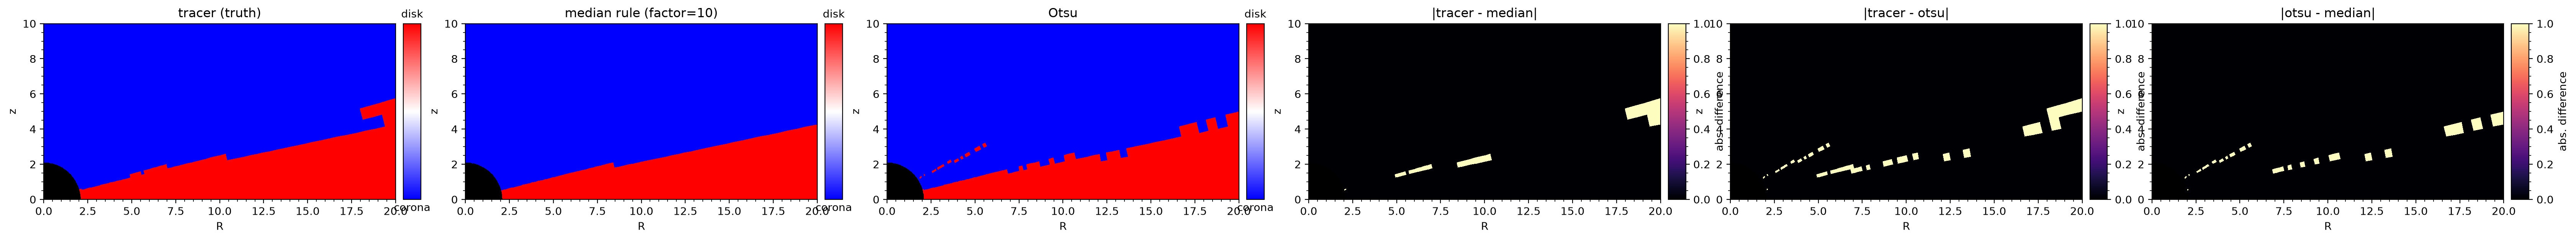

In [45]:
path = 'BH_VISC_HD/'
plot_classifier_comparison(path)

In [69]:
def animate_tracer(path, tracer, compare=False):
    """
    tracer: one of ['truth', 'median', 'otsu'] -> field to animate
    compare: False, or one of ['truth', 'median', 'otsu'] (excluding `tracer`)
             -> instead animates abs(field_A - field_B) in grayscale

    'truth' uses the raw continuous tr1 value (not thresholded).
    'median' and 'otsu' are binary 0/1 classifiers, each additionally gated
    by a rotation veto (vphi > vphi_frac * vK) to reject high-latitude
    outflow material that is dense but not rotating like the disk.
    """
    from skimage.filters import threshold_otsu

    # ---- hardcoded options (edit here) ----
    median_factor = 3
    vphi_frac = 0.3
    # ----------------------------------------

    if compare == tracer:
        raise ValueError("compare must differ from tracer, or be False")
    if tracer not in ('truth', 'median', 'otsu'):
        raise ValueError("tracer must be one of 'truth', 'median', 'otsu'")
    if compare not in (False, 'truth', 'median', 'otsu'):
        raise ValueError("compare must be False or one of 'truth', 'median', 'otsu'")

    def rotation_mask(vphi, R, Theta):
        Rcyl = R * np.sin(Theta)
        vK = 1. / np.sqrt(Rcyl)
        return vphi > vphi_frac * vK

    def otsu_field(rho, vphi, R, Theta):
        field = np.zeros_like(rho)
        for i in range(rho.shape[0]):
            logrho = np.log10(np.clip(rho[i, :], 1e-30, None))
            if logrho.max() - logrho.min() < 1e-6:
                continue
            t = threshold_otsu(logrho)
            field[i, :] = (logrho > t).astype(float)
        rot = rotation_mask(vphi, R, Theta)
        field[~rot] = 0.0
        return field

    def median_field(rho, vphi, R, Theta, factor):
        field = np.zeros_like(rho)
        for i in range(rho.shape[0]):
            med = np.median(rho[i, :])
            field[i, :] = (rho[i, :] > factor * med).astype(float)
        rot = rotation_mask(vphi, R, Theta)
        field[~rot] = 0.0
        return field

    def get_field(Di, which, R, Theta):
        if which == 'truth':
            return Di.tr1
        elif which == 'median':
            return median_field(Di.rho, Di.vx3, R, Theta, median_factor)
        elif which == 'otsu':
            return otsu_field(Di.rho, Di.vx3, R, Theta)

    D_last = pp.Load(nout='last', path=path)
    unique_outs = list(D_last.outlist)
    if 'STAR' in path:
        times = D_last.timelist / 62.8318
    elif 'BH' in path:
        times = D_last.timelist
    R, Theta = np.meshgrid(D_last.x1, D_last.x2, indexing='ij')
    X = R * np.sin(Theta)
    Z = R * np.cos(Theta)

    mask = (X >= 0) & (X <= 21) & (Z >= 0) & (Z <= 11)

    field_frames = {}
    for i in unique_outs:
        Di = pp.Load(nout=i, path=path)
        if compare:
            field_a = get_field(Di, tracer, R, Theta)
            field_b = get_field(Di, compare, R, Theta)
            data = np.abs(field_a - field_b)
        else:
            data = get_field(Di, tracer, R, Theta)
        field_frames[i] = np.where(mask, data, np.nan)

    if 'STAR' in path:
        outlist = [unique_outs[0]] * 10 + unique_outs + [unique_outs[-1]] * 10
    elif 'BH' in path:
        outlist = [unique_outs[0]] * 20 + unique_outs + [unique_outs[-1]] * 20

    frames = []
    for i in outlist:
        fig, ax = plt.subplots(figsize=[6, 8])
        ax.set_facecolor('k')

        if compare:
            cmap = 'gray'
        else:
            cmap = 'bwr'

        im = ax.pcolormesh(
            X, Z, field_frames[i],
            cmap=cmap,
            vmin=0, vmax=1,
            shading='auto'
        )

        ax.set_xlabel('R')
        ax.set_ylabel('z')
        ax.set_aspect('equal')

        ax.set_xlim(0, 20)
        ax.set_ylim(0, 10)
        if 'STAR' in path:
            ax.add_patch(Wedge((0.0, 0.0), 1.0, 0.0, 90, facecolor='w', edgecolor=None))
            ax.plot([], [], ' ', label=f't = {times[i]:.1f}')
        elif 'BH' in path:
            ax.add_patch(Wedge((0.0, 0.0), 2.1, 0.0, 90, facecolor='k', edgecolor=None))
            ax.plot([], [], ' ', label=f't = {times[i]:.0f}')
        ax.legend(loc='upper right', labelcolor='w')

        divider = make_axes_locatable(ax)
        if compare:
            cax = divider.append_axes("right", size="5%", pad=0.1)
        else:
            cax = divider.append_axes("right", size="5%", pad=0.4)
        cbar = fig.colorbar(im, cax=cax)

        if compare:
            cbar.set_label('|Δ|')
        else:
            cbar.set_ticks([])
            cax.text(0.5, 1.02, 'disk', transform=cax.transAxes,
                      ha='center', va='bottom', color='k', fontsize=10)
            cax.text(0.5, -0.02, 'corona', transform=cax.transAxes,
                      ha='center', va='top', color='k', fontsize=10)

        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=200, bbox_inches='tight')
        plt.close(fig)
        buf.seek(0)
        img = Image.open(buf)
        img.load()
        frames.append(img.convert('RGB'))

    if compare:
        gif_name = f'tracer_{tracer}_{compare}.gif'
    else:
        gif_name = f'tracer_{tracer}.gif'
    gif_path = f'{path}/Storage/{gif_name}'
    frames[0].save(
        gif_path,
        format='GIF',
        save_all=True,
        append_images=frames[1:],
        duration=150,
        loop=0
    )

    ipd.display(ipd.HTML(f'<img src="{gif_path}" width="750">'))

In [70]:
path = 'BH_VISC_RES_MHD/'
animate_tracer(path, 'median')

In [64]:
path = 'BH_VISC_RES_MHD/'
animate_tracer(path, 'otsu')

In [65]:
path = 'BH_VISC_RES_MHD/'
animate_tracer(path, 'truth')

In [71]:
path = 'BH_VISC_RES_MHD/'
animate_tracer(path, 'median', 'truth')

In [67]:
path = 'BH_VISC_RES_MHD/'
animate_tracer(path, 'otsu', 'median')

In [68]:
path = 'BH_VISC_RES_MHD/'
animate_tracer(path, 'truth', 'otsu')

In [104]:
def animate_tracer(path, tracer, compare=False):
    """
    tracer: one of ['truth', 'median', 'otsu'] -> field to animate
    compare: False, or one of ['truth', 'median', 'otsu'] (excluding `tracer`)
             -> instead animates (field_A - field_B), signed, in [-1, 1]
             -> also produces a separate comparison.gif with per-radius
                agreement fraction vs frame

    'truth' uses the raw continuous tr1 value (not thresholded).
    'median' and 'otsu' are binary 0/1 classifiers, each additionally gated
    by a rotation veto (vphi > vphi_frac * vK) to reject high-latitude
    outflow material that is dense but not rotating like the disk.
    """
    from skimage.filters import threshold_otsu

    ### ================================== ###
    median_factor = 5.0
    vphi_frac = 0.5
    agreement_tol = 0.5
    ### ================================== ###

    if compare == tracer:
        raise ValueError("compare must differ from tracer, or be False")
    if tracer not in ('truth', 'median', 'otsu'):
        raise ValueError("tracer must be one of 'truth', 'median', 'otsu'")
    if compare not in (False, 'truth', 'median', 'otsu'):
        raise ValueError("compare must be False or one of 'truth', 'median', 'otsu'")

    def rotation_mask(vphi, R, Theta):
        Rcyl = R * np.sin(Theta)
        vK = 1. / np.sqrt(Rcyl)
        return vphi > vphi_frac * vK

    def otsu_field(rho, vphi, R, Theta):
        field = np.zeros_like(rho)
        for i in range(rho.shape[0]):
            logrho = np.log10(np.clip(rho[i, :], 1e-30, None))
            if logrho.max() - logrho.min() < 1e-6:
                continue
            t = threshold_otsu(logrho)
            field[i, :] = (logrho > t).astype(float)
        rot = rotation_mask(vphi, R, Theta)
        field[~rot] = 0.0
        return field

    def median_field(rho, vphi, R, Theta, factor):
        field = np.zeros_like(rho)
        for i in range(rho.shape[0]):
            med = np.median(rho[i, :])
            field[i, :] = (rho[i, :] > factor * med).astype(float)
        rot = rotation_mask(vphi, R, Theta)
        field[~rot] = 0.0
        return field

    def get_field(Di, which, R, Theta):
        if which == 'truth':
            return Di.tr1
        elif which == 'median':
            return median_field(Di.rho, Di.vx3, R, Theta, median_factor)
        elif which == 'otsu':
            return otsu_field(Di.rho, Di.vx3, R, Theta)

    D_last = pp.Load(nout='last', path=path)
    unique_outs = list(D_last.outlist)
    if 'STAR' in path:
        times = D_last.timelist / 62.8318
    elif 'BH' in path:
        times = D_last.timelist
    R, Theta = np.meshgrid(D_last.x1, D_last.x2, indexing='ij')
    X = R * np.sin(Theta)
    Z = R * np.cos(Theta)

    mask = (X >= 0) & (X <= 21) & (Z >= 0) & (Z <= 11)

    field_frames = {}
    agreement_frames = {}
    for i in unique_outs:
        Di = pp.Load(nout=i, path=path)
        if compare:
            field_a = get_field(Di, tracer, R, Theta)
            field_b = get_field(Di, compare, R, Theta)
            data = field_a - field_b
            agree = (np.abs(data) < agreement_tol).astype(float)
            agreement_frames[i] = np.mean(agree, axis=1)  # per-radius, avg over theta
        else:
            data = get_field(Di, tracer, R, Theta)
        field_frames[i] = np.where(mask, data, np.nan)

    if 'STAR' in path:
        outlist = [unique_outs[0]] * 10 + unique_outs + [unique_outs[-1]] * 10
    elif 'BH' in path:
        outlist = [unique_outs[0]] * 20 + unique_outs + [unique_outs[-1]] * 20

    vmin, vmax = (-1, 1) if compare else (0, 1)

    frames = []
    for i in outlist:
        fig, ax = plt.subplots(figsize=[6, 8])
        ax.set_facecolor('k')

        im = ax.pcolormesh(
            X, Z, field_frames[i],
            cmap='coolwarm',
            vmin=vmin, vmax=vmax,
            shading='auto'
        )

        ax.set_xlabel('R')
        ax.set_ylabel('z')
        ax.set_aspect('equal')

        ax.set_xlim(0, 20)
        ax.set_ylim(0, 10)
        if 'STAR' in path:
            ax.add_patch(Wedge((0.0, 0.0), 1.0, 0.0, 90, facecolor='w', edgecolor=None))
            ax.plot([], [], ' ', label=f't = {times[i]:.1f}')
        elif 'BH' in path:
            ax.add_patch(Wedge((0.0, 0.0), 2.1, 0.0, 90, facecolor='k', edgecolor=None))
            ax.plot([], [], ' ', label=f't = {times[i]:.0f}')
        ax.legend(loc='upper right', labelcolor='w')

        divider = make_axes_locatable(ax)
        if compare:
            cax = divider.append_axes("right", size="5%", pad=0.1)
        else:
            cax = divider.append_axes("right", size="5%", pad=0.4)
        cbar = fig.colorbar(im, cax=cax)

        if compare:
            cbar.set_label('Δ (A - B)')
        else:
            cbar.set_ticks([])
            cax.text(0.5, 1.02, 'disk', transform=cax.transAxes,
                      ha='center', va='bottom', color='k', fontsize=10)
            cax.text(0.5, -0.02, 'corona', transform=cax.transAxes,
                      ha='center', va='top', color='k', fontsize=10)

        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=200, bbox_inches='tight')
        plt.close(fig)
        buf.seek(0)
        img = Image.open(buf)
        img.load()
        frames.append(img.convert('RGB'))

    if compare:
        gif_name = f'tracer_{tracer}_{compare}.gif'
    else:
        gif_name = f'tracer_{tracer}.gif'
    gif_path = f'{path}/Storage/{gif_name}'
    frames[0].save(
        gif_path,
        format='GIF',
        save_all=True,
        append_images=frames[1:],
        duration=150,
        loop=0
    )

    ipd.display(ipd.HTML(f'<img src="{gif_path}" width="750">'))

    if compare:
        x1 = D_last.x1
        comp_frames = []
        for i in outlist:
            fig, ax = plt.subplots(figsize=[7, 4])
            ax.plot(x1, agreement_frames[i], color='C0')
            ax.set_xlabel('R')
            ax.set_ylabel('agreement fraction')
            ax.set_ylim(0, 1)
            ax.set_xlim(x1.min(), x1.max())
            if 'STAR' in path:
                ax.set_title(f't = {times[i]:.1f}')
            elif 'BH' in path:
                ax.set_title(f't = {times[i]:.0f}')
            ax.grid(alpha=0.3)

            buf = io.BytesIO()
            fig.savefig(buf, format='png', dpi=200, bbox_inches='tight')
            plt.close(fig)
            buf.seek(0)
            img = Image.open(buf)
            img.load()
            comp_frames.append(img.convert('RGB'))

        comp_gif_path = f'{path}/Storage/comparison.gif'
        comp_frames[0].save(
            comp_gif_path,
            format='GIF',
            save_all=True,
            append_images=comp_frames[1:],
            duration=150,
            loop=0
        )

        ipd.display(ipd.HTML(f'<img src="{comp_gif_path}" width="650">'))

In [105]:
path = 'BH_VISC_MHD/'
animate_tracer(path, 'median')

In [106]:
path = 'BH_VISC_MHD/'
animate_tracer(path, 'median', 'truth')